# Notebook 08: Profiling and Error Analysis

This notebook profiles the dataset and performs structured error analysis to inform model development.

## Objectives
1. **Data integrity**: Verify schema and splits consistency
2. **Label distribution**: Analyze class balance by task type
3. **Response profiling**: Length distributions and percentiles
4. **Feature correlations**: Engineered features vs label + multicollinearity
5. **Error analysis**: Extract and categorize high-confidence errors

## Outputs
All artifacts saved to: `reports/nb08_profiling/`

## 1. Setup

In [1]:
import sys
from pathlib import Path

# Project root
ROOT = Path("..").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print("Repo root:", ROOT)
print("src exists:", (ROOT / "src").exists())

Repo root: /Users/aviv.gross/hallu-detect
src exists: True


In [2]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

# Project utilities
from src.data.load_splits import load_splits
from src.features.response_features import add_numeric_feature_columns, get_numeric_feature_cols
from src.utils.experiment import seed_everything, make_run_dir, get_model_scores, save_predictions_csv
from src.utils.eval import evaluate_split_with_roc
from src.utils.error_analysis import extract_top_errors, generate_error_report

# Plotting defaults
sns.set_style("whitegrid")
pd.set_option("display.max_colwidth", 100)

# Reproducibility
SEED = 42
seed_everything(SEED)

# Output directory (stable path)
REPORTS_DIR = ROOT / "reports"
RUN_DIR = make_run_dir(REPORTS_DIR, "nb08_profiling", timestamp=False)
PLOTS_DIR = RUN_DIR / "plots"
PLOTS_DIR.mkdir(exist_ok=True)

print(f"\nOutput directory: {RUN_DIR.relative_to(ROOT)}")
print(f"Plots directory:  {PLOTS_DIR.relative_to(ROOT)}")


Output directory: reports/nb08_profiling
Plots directory:  reports/nb08_profiling/plots


## 2. Load Data + Integrity Checks

In [3]:
# Load splits
train_df, val_df, test_df = load_splits(root=ROOT)

print("Split shapes:")
print(f"  Train: {train_df.shape}")
print(f"  Val:   {val_df.shape}")
print(f"  Test:  {test_df.shape}")

Split shapes:
  Train: (51647, 7)
  Val:   (6425, 7)
  Test:  (6435, 7)


In [4]:
print("=" * 70)
print("DATA INTEGRITY CHECKS")
print("=" * 70)

# 1. Required columns
required_cols = ["id", "group_id", "task", "prompt", "response", "label", "context"]
for split_name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    missing = set(required_cols) - set(df.columns)
    assert not missing, f"{split_name}: missing columns {missing}"
print("✓ All required columns present in all splits")

# 2. Binary labels {0, 1}
for split_name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    unique_labels = set(df["label"].unique())
    assert unique_labels.issubset({0, 1}), f"{split_name}: non-binary labels {unique_labels}"
print("✓ Labels are binary {0, 1} in all splits")

# 3. Task distribution non-empty
all_tasks = pd.concat([train_df["task"], val_df["task"], test_df["task"]])
task_counts = all_tasks.value_counts()
assert len(task_counts) > 0, "No tasks found"
print(f"✓ Task types found: {sorted(task_counts.index.tolist())}")
print(f"  Task counts: {task_counts.to_dict()}")

# 4. Group ID counts per split (leakage sanity check)
print("\n✓ Unique group_ids per split:")
for split_name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    n_groups = df["group_id"].nunique()
    print(f"  {split_name}: {n_groups} unique groups")

# 5. No group overlap (verify splits are clean)
train_groups = set(train_df["group_id"])
val_groups = set(val_df["group_id"])
test_groups = set(test_df["group_id"])

overlap_train_val = train_groups & val_groups
overlap_train_test = train_groups & test_groups
overlap_val_test = val_groups & test_groups

assert not overlap_train_val, f"Group overlap train/val: {len(overlap_train_val)}"
assert not overlap_train_test, f"Group overlap train/test: {len(overlap_train_test)}"
assert not overlap_val_test, f"Group overlap val/test: {len(overlap_val_test)}"
print("\n✓ No group_id overlap between splits (clean split)")

print("\n" + "=" * 70)
print("ALL INTEGRITY CHECKS PASSED")
print("=" * 70)

DATA INTEGRITY CHECKS
✓ All required columns present in all splits
✓ Labels are binary {0, 1} in all splits
✓ Task types found: ['dialogue', 'general', 'qa', 'summarization']
  Task counts: {'dialogue': 20000, 'qa': 20000, 'summarization': 20000, 'general': 4507}

✓ Unique group_ids per split:
  train: 27605 unique groups
  val: 3451 unique groups
  test: 3451 unique groups

✓ No group_id overlap between splits (clean split)

ALL INTEGRITY CHECKS PASSED


## 3. Label Distribution by Task

In [5]:
# Compute label distribution by task for each split
label_dist = []

for split_name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    for task in sorted(df["task"].unique()):
        task_df = df[df["task"] == task]
        n_total = len(task_df)
        n_hall = (task_df["label"] == 1).sum()
        n_non_hall = (task_df["label"] == 0).sum()
        pct_hall = 100.0 * n_hall / n_total if n_total > 0 else 0
        
        label_dist.append({
            "split": split_name,
            "task": task,
            "n_total": n_total,
            "n_hallucination": n_hall,
            "n_non_hallucination": n_non_hall,
            "pct_hallucination": pct_hall
        })

label_dist_df = pd.DataFrame(label_dist)

# Save to CSV
out_path = RUN_DIR / "label_distribution_by_task.csv"
label_dist_df.to_csv(out_path, index=False)
print(f"Saved: {out_path.relative_to(ROOT)}")

# Display
print("\nLabel distribution by task:")
print(label_dist_df.to_string(index=False))

Saved: reports/nb08_profiling/label_distribution_by_task.csv

Label distribution by task:
split          task  n_total  n_hallucination  n_non_hallucination  pct_hallucination
train      dialogue    16020             8010                 8010               50.0
train       general     3563                0                 3563                0.0
train            qa    16010             8005                 8005               50.0
train summarization    16054             8027                 8027               50.0
  val      dialogue     1938              969                  969               50.0
  val       general      477                0                  477                0.0
  val            qa     2008             1004                 1004               50.0
  val summarization     2002             1001                 1001               50.0
 test      dialogue     2042             1021                 1021               50.0
 test       general      467                0     

## 4. Response Length Profiling

Analyze response length distributions by label to identify patterns.

In [6]:
# Compute response lengths
def compute_response_stats(df, split_name):
    """Compute response length statistics by label."""
    df = df.copy()
    df["response_chars"] = df["response"].fillna("").astype(str).str.len()
    df["response_tokens"] = df["response"].fillna("").astype(str).str.split().str.len()
    
    stats = []
    for label in [0, 1]:
        subset = df[df["label"] == label]
        chars = subset["response_chars"]
        tokens = subset["response_tokens"]
        
        stats.append({
            "split": split_name,
            "label": label,
            "n": len(subset),
            # Character stats
            "chars_mean": chars.mean(),
            "chars_std": chars.std(),
            "chars_p50": chars.quantile(0.5),
            "chars_p90": chars.quantile(0.9),
            "chars_p95": chars.quantile(0.95),
            "pct_very_short_chars": 100.0 * (chars < 100).sum() / len(chars),
            # Token stats (proxy)
            "tokens_mean": tokens.mean(),
            "tokens_std": tokens.std(),
            "tokens_p50": tokens.quantile(0.5),
            "tokens_p90": tokens.quantile(0.9),
            "tokens_p95": tokens.quantile(0.95),
            "pct_very_short_tokens": 100.0 * (tokens < 20).sum() / len(tokens),
        })
    
    return stats

# Compute for all splits
response_stats = []
for split_name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    response_stats.extend(compute_response_stats(df, split_name))

response_stats_df = pd.DataFrame(response_stats)

# Save to CSV
out_path = RUN_DIR / "response_length_by_label.csv"
response_stats_df.to_csv(out_path, index=False)
print(f"Saved: {out_path.relative_to(ROOT)}")

# Display
print("\nResponse length statistics by label:")
print(response_stats_df.to_string(index=False))

Saved: reports/nb08_profiling/response_length_by_label.csv

Response length statistics by label:
split  label     n  chars_mean  chars_std  chars_p50  chars_p90  chars_p95  pct_very_short_chars  tokens_mean  tokens_std  tokens_p50  tokens_p90  tokens_p95  pct_very_short_tokens
train      0 27605  178.161637 202.021340       92.0      454.0     610.00             51.852925    29.928564   33.050342        17.0        77.0       101.0              53.048361
train      1 24042  204.358581 191.547732      116.0      511.0     592.00             43.507196    34.228600   31.384022        20.0        84.0        98.0              48.556692
  val      0  3451  177.724717 198.313932       92.0      448.0     608.50             51.376413    29.829325   32.460216        17.0        74.0       100.0              52.651405
  val      1  2974  201.862811 189.625573      117.0      504.7     581.35             44.283793    33.743443   30.991244        20.0        83.0        95.0              48.31876

## 5. Feature Engineering

Add engineered numeric features to all splits.

In [7]:
# Add numeric features
train_feat = add_numeric_feature_columns(train_df, response_col="response")
val_feat = add_numeric_feature_columns(val_df, response_col="response")
test_feat = add_numeric_feature_columns(test_df, response_col="response")

# Get feature column names
numeric_cols = get_numeric_feature_cols(train_feat)

print(f"Engineered features ({len(numeric_cols)}):")
for col in numeric_cols:
    print(f"  - {col}")

# Sanity check: no NaNs
for split_name, df in [("train", train_feat), ("val", val_feat), ("test", test_feat)]:
    n_nan = df[numeric_cols].isna().sum().sum()
    assert n_nan == 0, f"{split_name}: {n_nan} NaNs in numeric features"
print("\n✓ No NaNs in numeric features")

Engineered features (10):
  - resp_n_chars
  - resp_n_words
  - resp_n_punct
  - resp_has_multi_excl
  - resp_has_multi_q
  - resp_has_ellipsis
  - resp_n_numbers
  - resp_n_uncertainty
  - resp_punct_per_word
  - resp_numbers_per_word

✓ No NaNs in numeric features


## 6. Correlation Analysis

Analyze correlations between:
1. Features and label (point-biserial)
2. Features and features (multicollinearity check)

In [8]:
# Feature-label correlations (train set)
feature_label_corr = []
for col in numeric_cols:
    corr = train_feat[[col, "label"]].corr().iloc[0, 1]
    feature_label_corr.append({
        "feature": col,
        "corr_with_label": corr
    })

feature_label_corr_df = pd.DataFrame(feature_label_corr)
feature_label_corr_df = feature_label_corr_df.sort_values("corr_with_label", key=abs, ascending=False)

# Save
out_path = RUN_DIR / "feature_label_corr.csv"
feature_label_corr_df.to_csv(out_path, index=False)
print(f"Saved: {out_path.relative_to(ROOT)}")

# Display top correlations
print("\nTop features by correlation with label:")
print(feature_label_corr_df.head(10).to_string(index=False))

Saved: reports/nb08_profiling/feature_label_corr.csv

Top features by correlation with label:
              feature  corr_with_label
resp_numbers_per_word        -0.134115
       resp_n_numbers        -0.101709
         resp_n_chars         0.066990
         resp_n_words         0.066291
         resp_n_punct        -0.047068
    resp_has_ellipsis        -0.025168
   resp_n_uncertainty        -0.021032
  resp_punct_per_word         0.017357
  resp_has_multi_excl        -0.009107
     resp_has_multi_q        -0.004107


Saved: reports/nb08_profiling/feature_corr_matrix.csv
Saved: reports/nb08_profiling/plots/numeric_correlations.png


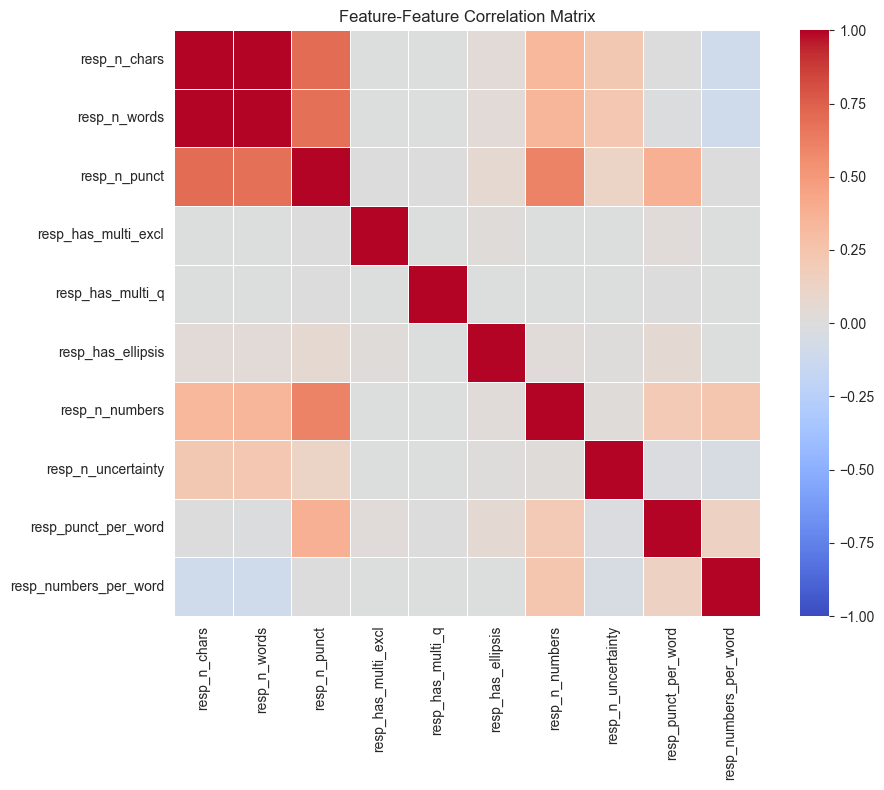

Saved: reports/nb08_profiling/plots/feature_label_corr.png


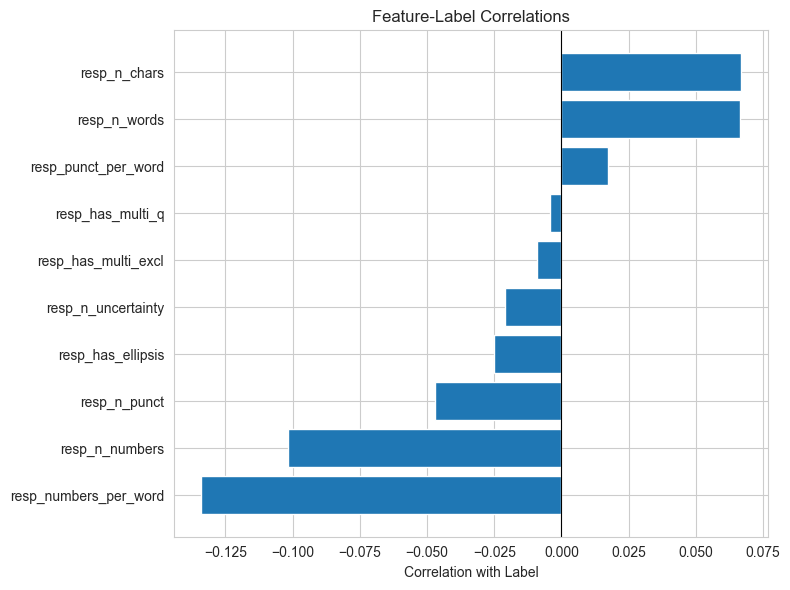

In [9]:
# Feature-feature correlation matrix
feature_corr_matrix = train_feat[numeric_cols].corr()

# Save
out_path = RUN_DIR / "feature_corr_matrix.csv"
feature_corr_matrix.to_csv(out_path)
print(f"Saved: {out_path.relative_to(ROOT)}")

# Plot heatmap
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(feature_corr_matrix, annot=False, cmap="coolwarm", center=0, 
            vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax)
ax.set_title("Feature-Feature Correlation Matrix")
plt.tight_layout()

out_path = PLOTS_DIR / "numeric_correlations.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"Saved: {out_path.relative_to(ROOT)}")
plt.show()

# Optional: Bar chart for feature-label correlations
fig, ax = plt.subplots(figsize=(8, 6))
sorted_df = feature_label_corr_df.sort_values("corr_with_label")
ax.barh(sorted_df["feature"], sorted_df["corr_with_label"])
ax.set_xlabel("Correlation with Label")
ax.set_title("Feature-Label Correlations")
ax.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()

out_path = PLOTS_DIR / "feature_label_corr.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"Saved: {out_path.relative_to(ROOT)}")
plt.show()

## 7. Train Quick Model for Error Analysis

Train TF-IDF + numeric features baseline for error extraction.

In [10]:
# Build pipeline: TF-IDF on response + scaled numeric features
tfidf = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    max_features=50000
)

preprocessor = ColumnTransformer(
    transformers=[
        ("tfidf", tfidf, "response"),
        ("num", StandardScaler(), numeric_cols)
    ],
    remainder="drop",
    sparse_threshold=0.3
)

clf = Pipeline([
    ("preprocess", preprocessor),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=SEED, n_jobs=-1))
])

# Train
print("Training TF-IDF + numeric features baseline...")
y_train = train_feat["label"].values
clf.fit(train_feat, y_train)
print("✓ Model trained")

Training TF-IDF + numeric features baseline...


/Users/aviv.gross/hallu-detect/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


✓ Model trained


In [11]:
# Evaluate
y_val = val_feat["label"].values
y_test = test_feat["label"].values

train_metrics = evaluate_split_with_roc("Train", clf, train_feat, y_train, verbose=True)
val_metrics = evaluate_split_with_roc("Val", clf, val_feat, y_val, verbose=True)
test_metrics = evaluate_split_with_roc("Test", clf, test_feat, y_test, verbose=True)


Train metrics:
  accuracy = 0.8808
  f1       = 0.8730
  precision= 0.8660
  recall   = 0.8800
  roc_auc  = 0.9502
  confusion matrix:
[[24332  3273]
 [ 2885 21157]]

Val metrics:
  accuracy = 0.8330
  f1       = 0.8205
  precision= 0.8165
  recall   = 0.8245
  roc_auc  = 0.9144
  confusion matrix:
[[2900  551]
 [ 522 2452]]

Test metrics:
  accuracy = 0.8325
  f1       = 0.8212
  precision= 0.8131
  recall   = 0.8294
  roc_auc  = 0.9088
  confusion matrix:
[[2882  569]
 [ 509 2475]]


## 8. Error Analysis

Extract high-confidence errors for deeper analysis.

In [12]:
# Save predictions for val and test
for split_name, df_feat, y_true in [("val", val_feat, y_val), ("test", test_feat, y_test)]:
    scores = get_model_scores(clf, df_feat)
    y_pred = (scores >= 0.5).astype(int)
    
    save_predictions_csv(
        path=RUN_DIR / f"predictions_{split_name}.csv",
        df=df_feat,
        y_true=y_true,
        y_pred=y_pred,
        scores=scores,
        split=split_name,
        verbose=True
    )

Saved predictions to: /Users/aviv.gross/hallu-detect/reports/nb08_profiling/predictions_val.csv
  Total: 6425, Correct: 5352, FP: 551, FN: 522
Saved predictions to: /Users/aviv.gross/hallu-detect/reports/nb08_profiling/predictions_test.csv
  Total: 6435, Correct: 5357, FP: 569, FN: 509


In [13]:
# Extract top errors from validation set
df_pred_val = pd.read_csv(RUN_DIR / "predictions_val.csv")

top_fp = extract_top_errors(df_pred_val, kind="fp", top_k=50)
top_fn = extract_top_errors(df_pred_val, kind="fn", top_k=50)

print(f"\nExtracted {len(top_fp)} false positives, {len(top_fn)} false negatives")

# Save
top_fp.to_csv(RUN_DIR / "top_fp.csv", index=False)
top_fn.to_csv(RUN_DIR / "top_fn.csv", index=False)
print(f"Saved: {(RUN_DIR / 'top_fp.csv').relative_to(ROOT)}")
print(f"Saved: {(RUN_DIR / 'top_fn.csv').relative_to(ROOT)}")


Extracted 50 false positives, 50 false negatives
Saved: reports/nb08_profiling/top_fp.csv
Saved: reports/nb08_profiling/top_fn.csv


In [14]:
# Generate error analysis report
generate_error_report(
    fp_df=top_fp,
    fn_df=top_fn,
    output_path=RUN_DIR / "error_report.md",
    top_n=10
)

print(f"\nSaved: {(RUN_DIR / 'error_report.md').relative_to(ROOT)}")

# Display report preview
report_text = (RUN_DIR / "error_report.md").read_text()
print("\n" + "=" * 70)
print("ERROR REPORT PREVIEW")
print("=" * 70)
print(report_text[:1000])
if len(report_text) > 1000:
    print("\n... [see full report in error_report.md]")


Saved: reports/nb08_profiling/error_report.md

ERROR REPORT PREVIEW
# Error Analysis Report

## Summary Statistics

- **Total errors**: 100
- **False positives (FP)**: 50 (predicted hallucination, true non-hallucination)
- **False negatives (FN)**: 50 (predicted non-hallucination, true hallucination)

## Top 10 False Positives (by confidence)

Model incorrectly predicted hallucination with high confidence.

| id                    | task          |    score |   confidence |   y_true |   y_pred |
|:----------------------|:--------------|---------:|-------------:|---------:|---------:|
| qa_111_gt             | qa            | 0.999874 |     0.999874 |        0 |        1 |
| general_752           | general       | 0.976649 |     0.976649 |        0 |        1 |
| dialogue_6611_gt      | dialogue      | 0.964834 |     0.964834 |        0 |        1 |
| dialogue_8486_gt      | dialogue      | 0.957511 |     0.957511 |        0 |        1 |
| dialogue_2729_gt      | dialogue      | 0.9404

## 9. Summary

All profiling and error analysis artifacts saved to: `reports/nb08_profiling/`

In [15]:
print("=" * 70)
print("NB08 PROFILING COMPLETE")
print("=" * 70)

print(f"\nOutput directory: {RUN_DIR.relative_to(ROOT)}")

print("\nGenerated artifacts:")
for f in sorted(RUN_DIR.rglob("*")):
    if f.is_file():
        print(f"  - {f.relative_to(ROOT)}")

print("\n" + "=" * 70)
print("INITIAL OBSERVATIONS (placeholders for manual analysis)")
print("=" * 70)
print("\n1. Label Distribution:")
print("   - [Examine class balance across tasks]")
print("\n2. Response Length Patterns:")
print("   - [Compare length distributions by label]")
print("\n3. Feature Correlations:")
print("   - [Identify strongest predictors from correlation analysis]")
print("\n4. Error Themes:")
print("   - [Review top FP/FN in error_report.md for patterns]")
print("\n5. Multicollinearity:")
print("   - [Check feature_corr_matrix.csv for highly correlated features]")
print("\n" + "=" * 70)

NB08 PROFILING COMPLETE

Output directory: reports/nb08_profiling

Generated artifacts:
  - reports/nb08_profiling/error_report.md
  - reports/nb08_profiling/feature_corr_matrix.csv
  - reports/nb08_profiling/feature_label_corr.csv
  - reports/nb08_profiling/label_distribution_by_task.csv
  - reports/nb08_profiling/plots/feature_label_corr.png
  - reports/nb08_profiling/plots/numeric_correlations.png
  - reports/nb08_profiling/predictions_test.csv
  - reports/nb08_profiling/predictions_val.csv
  - reports/nb08_profiling/response_length_by_label.csv
  - reports/nb08_profiling/top_fn.csv
  - reports/nb08_profiling/top_fp.csv

INITIAL OBSERVATIONS (placeholders for manual analysis)

1. Label Distribution:
   - [Examine class balance across tasks]

2. Response Length Patterns:
   - [Compare length distributions by label]

3. Feature Correlations:
   - [Identify strongest predictors from correlation analysis]

4. Error Themes:
   - [Review top FP/FN in error_report.md for patterns]

5. Mult